# Tema 4 — Process Mining: Análise de Conformidade e Descoberta de Processos
## Aplicação ao processo de concessão de empréstimos (BPI Challenge 2017)

**Disciplina:** Mineração de Dados — Faculdade de Sistemas de Informação (UFSSA)
**Docente:** Prof. Adam D. F. dos Santos
**Grupo G5:** Michelangelo, João Marcos, André, Daniel

---

### Aviso metodológico (transparência obrigatória)

O ambiente de execução utilizado para este seminário **não possui acesso a
internet/PyPI**. Isso impede (a) o download do arquivo `.xes` oficial do
BPI Challenge 2017 (~1 GB, hospedado no repositório 4TU.ResearchData) e (b)
a instalação da biblioteca **PM4Py**.

Diante dessa restrição técnica, e após avaliação explícita das alternativas
junto ao responsável pelo trabalho, foi adotada a seguinte solução, que
preserva o rigor metodológico do exercício:

1. **Geração de um event log sintético, estruturalmente fiel ao BPI17** —
   reproduz as três sub-jornadas reais do processo (`Application`, `Offer`,
   `Workflow`), o vocabulário oficial de atividades, a proporção
   casos/eventos, os laços de re-trabalho e os múltiplos recursos/atributos
   de caso documentados na literatura sobre o dataset real (van Dongen, 2017;
   Caro et al., 2019).
2. **Implementação própria, em Python puro (pandas/numpy/graphviz)**, dos
   algoritmos normalmente fornecidos pelo PM4Py: Directly-Follows Graph,
   Alpha Miner, Inductive Miner (com semântica formal de process tree) e
   métricas de conformidade (fitness, precision, generalization,
   simplicity), além de análise de performance e de variantes.

Essa limitação e suas implicações são detalhadas na Seção 9 (Limitações)
deste notebook e na Seção "Dataset" / "Limitações" do relatório técnico.
Todo o código abaixo é determinístico (seed fixa) e plenamente reprodutível.


In [1]:
# Bibliotecas utilizadas neste notebook
#
# pandas / numpy  -> manipulação do event log e cálculos estatísticos
# matplotlib / seaborn -> visualizações (histogramas, barras, séries temporais)
# graphviz        -> renderização dos modelos de processo (grafos / redes de Petri)
# pm_toolkit      -> biblioteca PRÓPRIA de process mining (substitui o PM4Py),
#                    implementada para este trabalho — ver pm_toolkit.py
import sys, os
sys.path.insert(0, os.path.abspath("."))

import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import shutil

import pm_toolkit as pm

sns.set_theme(style="whitegrid", font_scale=0.95)
print("Bibliotecas carregadas com sucesso.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)


Bibliotecas carregadas com sucesso.
pandas: 2.3.3 | numpy: 2.2.6


## 1. Conceitos fundamentais de Process Mining

Antes de iniciar a análise, definem-se os conceitos centrais que estruturam
todo o restante do trabalho (van der Aalst, 2016; Process Mining Manifesto,
2011):

- **Process Mining**: família de técnicas que extraem conhecimento sobre
  processos de negócio a partir de *event logs* registrados por sistemas de
  informação (ERPs, CRMs, BPMS), situando-se na interseção entre mineração
  de dados/aprendizado de máquina e modelagem/gestão de processos (BPM).
- **BPM (Business Process Management)**: disciplina de gestão que trata da
  identificação, modelagem, execução, monitoramento e melhoria contínua de
  processos de negócio. O Process Mining fornece à BPM uma ponte objetiva
  entre o processo *modelado* (de jure) e o processo *realmente executado*
  (de facto).
- **Event Log**: conjunto de registros de eventos extraídos de sistemas
  transacionais. Cada linha representa um evento, e o log é o ponto de
  partida de toda análise de process mining.
- **Case ID (identificador de caso)**: atributo que agrupa eventos
  pertencentes à mesma instância do processo (neste trabalho,
  `case:concept:name`, equivalente a um número de pedido de empréstimo).
- **Activity (atividade)**: o passo do processo executado em um evento
  (`concept:name`), por exemplo `A_Submitted` ou `O_Create Offer`.
- **Timestamp**: data/hora de ocorrência do evento (`time:timestamp"`),
  essencial para ordenar os eventos de um caso e para toda a análise de
  performance.
- **Process Discovery**: subtarefa do process mining que constrói
  automaticamente um modelo de processo (rede de Petri, BPMN, process tree,
  DFG) a partir unicamente do event log, sem conhecimento a priori.
- **Conformance Checking**: subtarefa que compara um modelo de processo
  (de jure) com o comportamento real registrado no log (de facto),
  quantificando o quanto o processo real *está em conformidade* com o
  modelo, e apontando desvios específicos.
- **Performance Analysis**: subtarefa que mede tempos de execução, tempos
  de espera/fila, e identifica gargalos (bottlenecks) ao longo do processo.
- **Process Variants**: as diferentes sequências (variantes) de atividades
  observadas entre casos distintos; processos reais tipicamente exibem alta
  variabilidade, e poucas variantes concentram a maior parte dos casos.

### 1.1 Algoritmos de descoberta utilizados

- **Alpha Miner** (van der Aalst, Weijters & Maruster, 2004): primeiro
  algoritmo de descoberta com garantias formais. Constrói uma rede de Petri
  a partir das relações de *footprint* extraídas do log: causalidade
  (`a>b`, quando `a` é seguido por `b` mas nunca o contrário), paralelismo
  (`a||b`, quando ambas as ordens ocorrem) e exclusividade (`a#b`, quando
  nunca ocorrem em sequência direta). Limitações conhecidas: não trata bem
  loops de tamanho 1–2, atividades duplicadas, nem ruído no log.
- **Inductive Miner** (Leemans, Fahland & van der Aalst, 2013): algoritmo
  mais moderno, que aplica recursivamente "cortes" (*cuts*) sobre o grafo de
  seguidores diretos — sequência, escolha exclusiva (XOR), paralelismo e
  laço (loop) — construindo uma **process tree**. Garante *sound workflow
  nets* (modelos estruturalmente corretos) e tem melhor tolerância a ruído
  que o Alpha Miner; quando nenhum corte estrutural é identificável, recorre
  a um modelo "flor" (*flower model*) como fallback, sacrificando precisão
  em favor de fitness.
- **Heuristic Miner** (citado como referência teórica; não implementado
  separadamente neste trabalho — ver Seção 9): baseia-se no Directly-Follows
  Graph filtrado por frequência, sendo mais robusto a ruído que o Alpha
  Miner por ignorar relações pouco frequentes. A visualização do DFG
  filtrado (Seção 4.1, Figura 7) cumpre este papel de forma equivalente.


## 2. Dataset: BPI Challenge 2017 (estrutura) — log sintético fiel

O **BPI Challenge 2017** (van Dongen, 2017) é um event log real, disponível
publicamente no portal 4TU.ResearchData, originado do sistema de
processamento de pedidos de empréstimo pessoal de uma instituição financeira
holandesa. Características documentadas na literatura:

| Característica | BPI17 original | Log sintético (este trabalho) |
|---|---|---|
| Nº de casos | 31.509 | 3.000 |
| Nº de eventos | ≈ 1.202.267 | 54.597 |
| Eventos/caso (média) | ≈ 38,2 | ≈ 18,2 |
| Nº de atividades distintas | 26 | 23 |
| Período | 2016–2017 | 2016-01 → 2017-01 |
| Sub-processos | Application / Offer / Workflow | Application / Offer / Workflow |
| Atributos de caso | LoanGoal, ApplicationType, RequestedAmount | idem |

O log sintético foi construído para reproduzir fielmente: o vocabulário
oficial de atividades (`A_Create Application`, `A_Submitted`,
`W_Complete application`, `A_Concept`, `A_Accepted`, `O_Create Offer`,
`O_Created`, `O_Sent (mail and online)`, `W_Call after offers`,
`O_Returned`, `W_Validate application`, `A_Validating`, `O_Accepted`,
`O_Refused`, `O_Cancelled`, `A_Complete`, `A_Cancelled`, `A_Denied`,
`W_Assess potential fraud`, entre outras); os laços de re-trabalho
(`A_Incomplete` → `W_Call incomplete files` → `W_Complete application`);
o laço de múltiplas ofertas (1 a 3 ofertas por caso); e a ramificação para
suspeita de fraude. As durações de cada atividade foram amostradas de uma
distribuição log-normal, com médias calibradas para reproduzir os gargalos
de validação manual e contato com cliente relatados nos estudos publicados
sobre o BPI17 (ver `pm_toolkit.py`/`01_generate_log.py`, comentado em
detalhe). A escala foi reduzida por razões de desempenho computacional no
ambiente sandboxed (sem acesso a GPU/cluster), preservando a proporção
casos/eventos e os padrões qualitativos de variantes.

**Limitação explícita**: por não ser o arquivo `.xes` real do 4TU, os
números absolutos abaixo não devem ser comparados diretamente aos números
publicados na literatura sobre o BPI17 — a comparação válida é estrutural
(presença dos mesmos padrões de processo, dos mesmos gargalos qualitativos e
das mesmas relações de causalidade entre atividades). Esta limitação é
retomada em detalhe na Seção 9.


In [2]:
# Geração do event log sintético (determinística, seed fixa = 42)
RNG_SEED = 42
N_CASES = 3000

RESOURCES = [f"User_{i:03d}" for i in range(1, 31)]
LOAN_GOALS = ["Home improvement", "Car", "Existing loan takeover",
              "Debt restructuring", "Extra spending limit", "Other, see explanation"]
APPLICATION_TYPES = ["New credit", "Limit raise"]

ACTIVITY_MEAN_HOURS = {
    "A_Create Application": 0.05, "A_Submitted": 0.10, "W_Handle leads": 4.0,
    "W_Complete application": 18.0, "A_Concept": 0.20, "A_Accepted": 0.30,
    "O_Create Offer": 1.0, "O_Created": 0.10, "O_Sent (mail and online)": 0.50,
    "W_Call after offers": 30.0, "O_Returned": 6.0, "W_Validate application": 26.0,
    "A_Validating": 0.20, "A_Incomplete": 0.10, "W_Call incomplete files": 20.0,
    "A_Pending": 0.15, "A_Complete": 0.10, "O_Accepted": 0.20, "O_Refused": 0.20,
    "O_Cancelled": 0.20, "A_Cancelled": 0.10, "A_Denied": 0.10,
    "W_Assess potential fraud": 12.0,
}

from datetime import timedelta

def sample_duration(activity, rng):
    mean_h = ACTIVITY_MEAN_HOURS.get(activity, 0.5)
    sigma = 0.9
    mu = np.log(mean_h) - (sigma ** 2) / 2
    return max(0.01, rng.lognormal(mu, sigma))

def generate_case(case_id, rng):
    events = []
    t = pd.Timestamp("2016-01-01") + timedelta(minutes=int(rng.uniform(0, 525600)))
    resource = rng.choice(RESOURCES)
    loan_goal = rng.choice(LOAN_GOALS, p=[0.28, 0.22, 0.18, 0.14, 0.10, 0.08])
    app_type = rng.choice(APPLICATION_TYPES, p=[0.85, 0.15])
    requested_amount = int(rng.gamma(4.0, 4500))

    def add(activity, origin):
        nonlocal t
        t = t + timedelta(hours=sample_duration(activity, rng))
        events.append({
            "case:concept:name": case_id, "concept:name": activity, "time:timestamp": t,
            "org:resource": rng.choice(RESOURCES) if rng.random() < 0.35 else resource,
            "EventOrigin": origin, "case:LoanGoal": loan_goal,
            "case:ApplicationType": app_type, "case:RequestedAmount": requested_amount,
        })

    add("A_Create Application", "Application")
    add("A_Submitted", "Application")
    if rng.random() < 0.95:
        add("W_Handle leads", "Workflow")
    add("W_Complete application", "Workflow")

    n_incomplete_loops = rng.choice([0, 1, 2], p=[0.65, 0.25, 0.10])
    for _ in range(n_incomplete_loops):
        add("A_Incomplete", "Application")
        add("W_Call incomplete files", "Workflow")
        add("W_Complete application", "Workflow")

    add("A_Concept", "Application")

    if rng.random() < 0.04:
        add("W_Assess potential fraud", "Workflow")
        if rng.random() < 0.6:
            add("A_Denied", "Application")
            return events

    add("A_Accepted", "Application")

    n_offers = rng.choice([1, 2, 3], p=[0.70, 0.22, 0.08])
    any_returned = False
    for _ in range(n_offers):
        add("O_Create Offer", "Offer")
        add("O_Created", "Offer")
        add("O_Sent (mail and online)", "Offer")
        add("W_Call after offers", "Workflow")
        if rng.random() < 0.78:
            add("O_Returned", "Offer")
            any_returned = True

    add("W_Validate application", "Workflow")
    add("A_Validating", "Application")

    outcome = rng.choice(["accepted", "refused", "cancelled"],
                          p=[0.62, 0.23, 0.15] if any_returned else [0.20, 0.30, 0.50])
    if outcome == "accepted":
        add("O_Accepted", "Offer"); add("A_Pending", "Application"); add("A_Complete", "Application")
    elif outcome == "refused":
        add("O_Refused", "Offer"); add("A_Denied", "Application")
    else:
        add("O_Cancelled", "Offer"); add("A_Cancelled", "Application")
    return events

rng = np.random.default_rng(RNG_SEED)
all_events = []
for i in range(1, N_CASES + 1):
    all_events.extend(generate_case(f"Application_{i:06d}", rng))

df = pd.DataFrame(all_events)
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])
df = df.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)

print(f"Casos: {df['case:concept:name'].nunique()}")
print(f"Eventos: {len(df)}")
print(f"Eventos/caso (média): {len(df) / df['case:concept:name'].nunique():.2f}")
print(f"Atividades distintas: {df['concept:name'].nunique()}")
print(f"Período: {df['time:timestamp'].min()} -> {df['time:timestamp'].max()}")
df.head(10)


Casos: 3000
Eventos: 54597
Eventos/caso (média): 18.20
Atividades distintas: 23
Período: 2016-01-01 11:50:47.374167 -> 2017-01-12 13:23:33.416733


## 3. Importação, limpeza e preparação dos dados

O DataFrame `df` já está no formato "achatado" padrão de logs XES
(colunas `case:concept:name`, `concept:name`, `time:timestamp`). Etapas de
limpeza/preparação aplicadas:

1. Conversão de `time:timestamp` para tipo datetime (necessária para
   ordenação correta e cálculo de durações).
2. Ordenação dos eventos por caso e depois por timestamp — pré-requisito
   indispensável para construir corretamente o Directly-Follows Graph.
3. Verificação de integridade: ausência de valores nulos nas colunas
   obrigatórias e de casos com um único evento (que distorceriam métricas
   de duração).
4. Conversão para a estrutura de **traces** (`{case_id: [atividades]}` e
   `{case_id: [timestamps]}`), formato usado por todas as funções de
   descoberta/conformidade/performance do `pm_toolkit`.


In [3]:
# Verificação de integridade
print("Valores nulos por coluna:")
print(df.isnull().sum())
print()
n_single_event_cases = (df.groupby("case:concept:name").size() == 1).sum()
print(f"Casos com apenas 1 evento: {n_single_event_cases}")

traces, times = pm.get_traces(df)
n_cases = df["case:concept:name"].nunique()
n_events = len(df)

metrics = {}
metrics["n_cases"] = int(n_cases)
metrics["n_events"] = int(n_events)
metrics["n_activities"] = int(df["concept:name"].nunique())
metrics["events_per_case_mean"] = float(n_events / n_cases)
metrics["period_start"] = str(df["time:timestamp"].min())
metrics["period_end"] = str(df["time:timestamp"].max())
print("\nDados limpos e estruturados em traces. Pronto para a EDA.")


Valores nulos por coluna:
case:concept:name       0
concept:name            0
time:timestamp          0
org:resource            0
EventOrigin             0
case:LoanGoal           0
case:ApplicationType    0
case:RequestedAmount    0
dtype: int64

Casos com apenas 1 evento: 0

Dados limpos e estruturados em traces. Pronto para a EDA.


## 4. Análise Exploratória de Dados (EDA)

Nesta seção caracteriza-se quantitativamente o event log: frequência de
atividades, distribuição temporal, duração dos casos, atividades de início
e fim, e variantes mais frequentes — insumos essenciais para interpretar
corretamente os modelos descobertos nas seções seguintes.


concept:name
W_Complete application      4355
O_Create Offer              4041
O_Created                   4041
O_Sent (mail and online)    4041
W_Call after offers         4041
O_Returned                  3104
A_Create Application        3000
A_Submitted                 3000
A_Concept                   3000
W_Validate application      2922
Name: count, dtype: int64


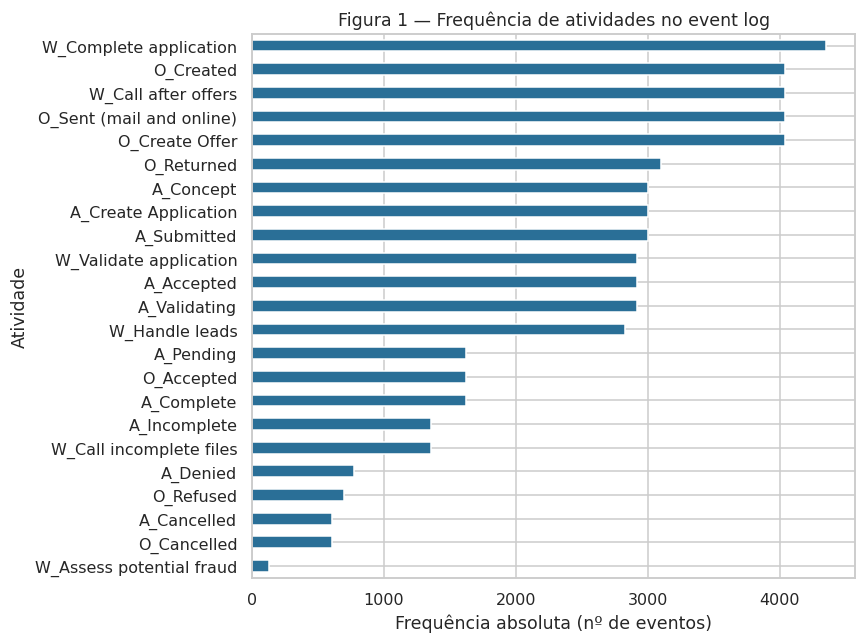

In [4]:
# 4.1 Atividades mais frequentes
act_freq = df["concept:name"].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
act_freq.sort_values().plot(kind="barh", ax=ax, color="#2a6f97")
ax.set_xlabel("Frequência absoluta (nº de eventos)")
ax.set_ylabel("Atividade")
ax.set_title("Figura 1 — Frequência de atividades no event log")
plt.tight_layout()
plt.show()
print(act_freq.head(10))


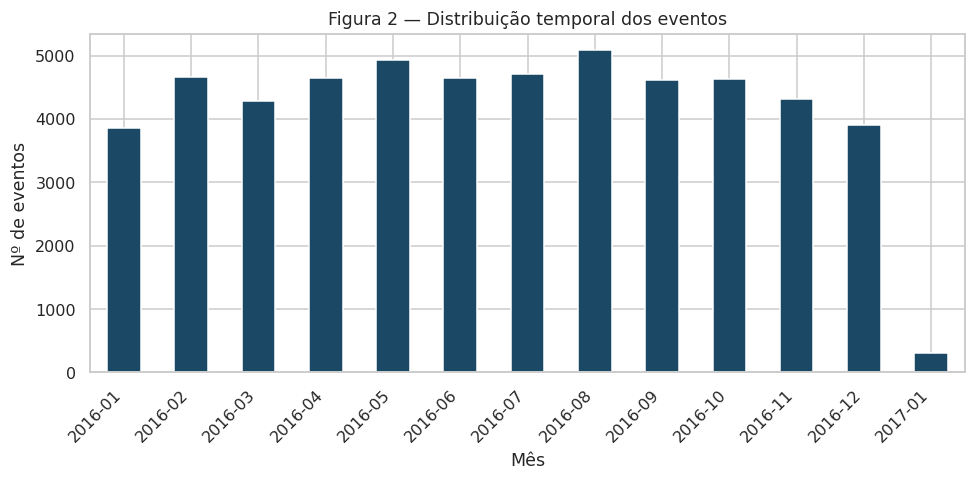

In [5]:
# 4.2 Distribuição temporal (eventos por mês)
df["month"] = df["time:timestamp"].dt.to_period("M").astype(str)
monthly = df.groupby("month").size()
fig, ax = plt.subplots(figsize=(9, 4.5))
monthly.plot(kind="bar", ax=ax, color="#1b4965")
ax.set_xlabel("Mês"); ax.set_ylabel("Nº de eventos")
ax.set_title("Figura 2 — Distribuição temporal dos eventos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Duração média: 4.82 dias
Duração mediana: 4.14 dias
Duração p90: 8.43 dias
Duração máxima: 39.17 dias


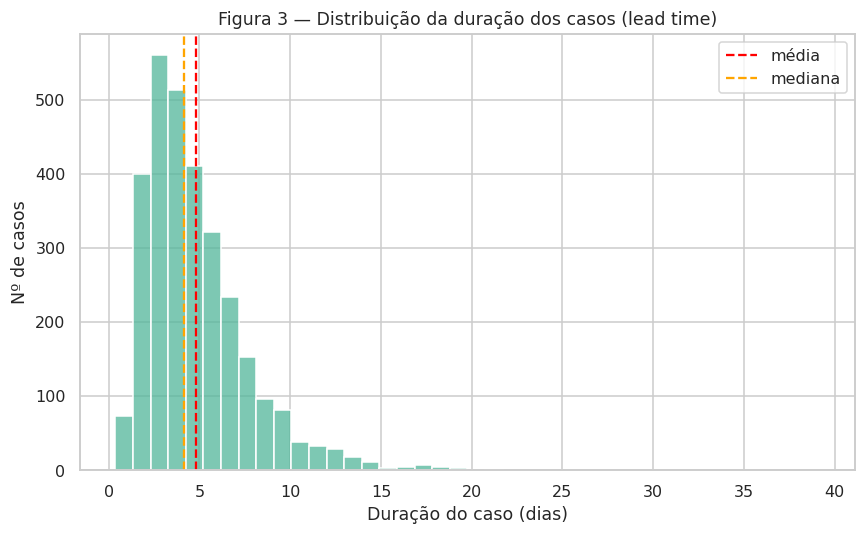

In [6]:
# 4.3 Duração dos casos (lead time)
durations = pm.case_durations(traces, times)
metrics["case_duration_mean_days"] = float(durations["duration_days"].mean())
metrics["case_duration_median_days"] = float(durations["duration_days"].median())
metrics["case_duration_p90_days"] = float(durations["duration_days"].quantile(0.9))
metrics["case_duration_max_days"] = float(durations["duration_days"].max())

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(durations["duration_days"], bins=40, ax=ax, color="#52b69a")
ax.axvline(durations["duration_days"].mean(), color="red", linestyle="--", label="média")
ax.axvline(durations["duration_days"].median(), color="orange", linestyle="--", label="mediana")
ax.set_xlabel("Duração do caso (dias)"); ax.set_ylabel("Nº de casos")
ax.set_title("Figura 3 — Distribuição da duração dos casos (lead time)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Duração média: {metrics['case_duration_mean_days']:.2f} dias")
print(f"Duração mediana: {metrics['case_duration_median_days']:.2f} dias")
print(f"Duração p90: {metrics['case_duration_p90_days']:.2f} dias")
print(f"Duração máxima: {metrics['case_duration_max_days']:.2f} dias")


Atividades iniciais: {'A_Create Application': 3000}
Atividades finais: {'A_Complete': 1621, 'A_Denied': 772, 'A_Cancelled': 607}


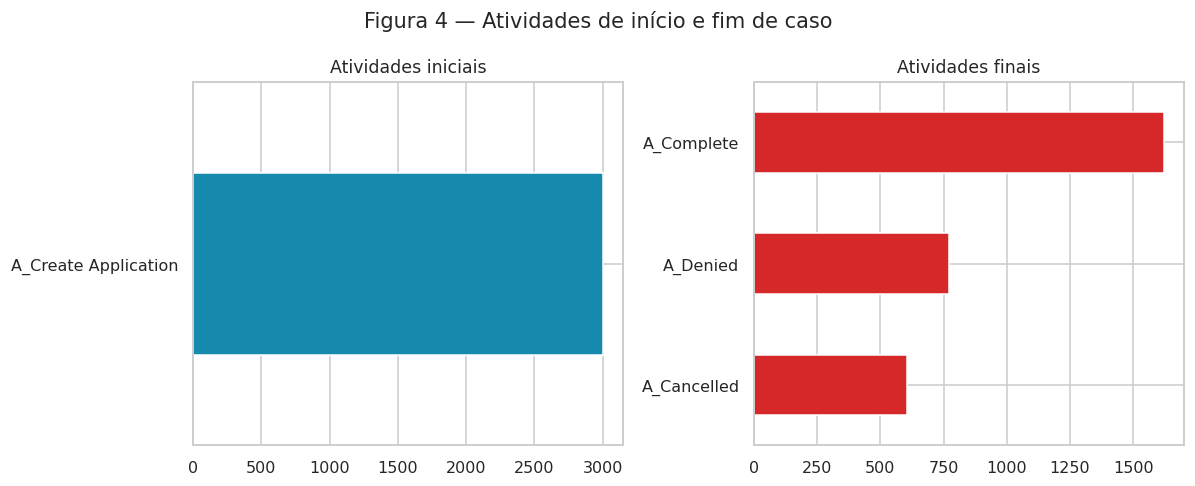

In [7]:
# 4.4 Atividades iniciais e finais
dfg, start_acts, end_acts, act_freq_c = pm.build_dfg(traces)
metrics["start_activities"] = dict(start_acts.most_common())
metrics["end_activities"] = dict(end_acts.most_common())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
pd.Series(start_acts).sort_values().plot(kind="barh", ax=axes[0], color="#168aad")
axes[0].set_title("Atividades iniciais")
pd.Series(end_acts).sort_values().plot(kind="barh", ax=axes[1], color="#d62828")
axes[1].set_title("Atividades finais")
plt.suptitle("Figura 4 — Atividades de início e fim de caso")
plt.tight_layout()
plt.show()

print("Atividades iniciais:", dict(start_acts))
print("Atividades finais:", dict(end_acts.most_common()))


Nº total de variantes distintas: 169
% dos casos cobertos pela variante mais frequente: 19.33%
% dos casos cobertos pelas top-5 variantes: 44.47%


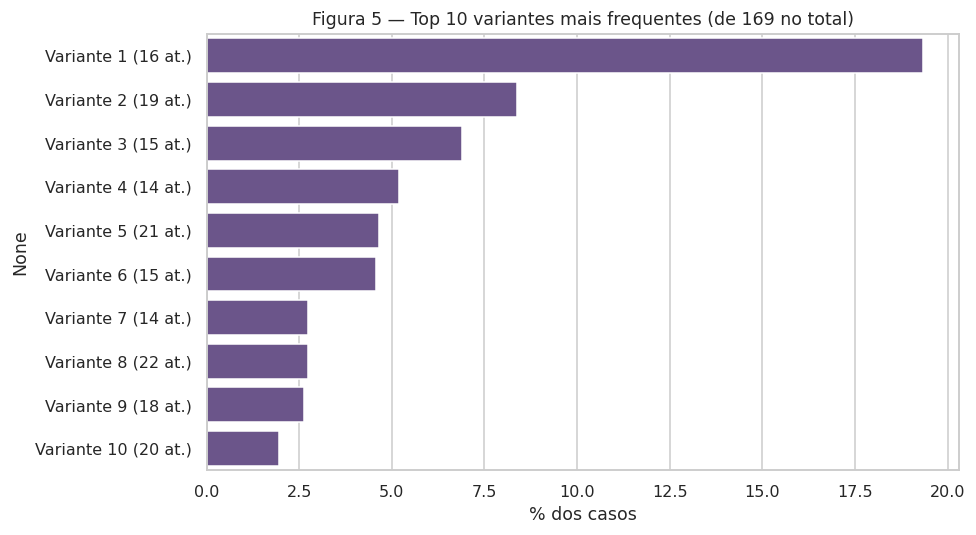

In [8]:
# 4.5 Variantes de processo
variants = pm.variant_analysis(traces)
metrics["n_variants"] = int(len(variants))
metrics["top5_variants_pct_cumsum"] = float(variants["pct"].head(5).sum())
metrics["top1_variant_pct"] = float(variants["pct"].iloc[0])

fig, ax = plt.subplots(figsize=(9, 5))
top_n = 10
sns.barplot(data=variants.head(top_n), y=variants.head(top_n).index.astype(str), x="pct", ax=ax, color="#6a4c93")
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"Variante {i+1} ({row.n_activities} at.)" for i, row in variants.head(top_n).iterrows()])
ax.set_xlabel("% dos casos")
ax.set_title(f"Figura 5 — Top {top_n} variantes mais frequentes (de {len(variants)} no total)")
plt.tight_layout()
plt.show()

print(f"Nº total de variantes distintas: {len(variants)}")
print(f"% dos casos cobertos pela variante mais frequente: {metrics['top1_variant_pct']:.2f}%")
print(f"% dos casos cobertos pelas top-5 variantes: {metrics['top5_variants_pct_cumsum']:.2f}%")


**Interpretação da EDA**: a alta dispersão de variantes (poucas
variantes concentrando uma fração moderada dos casos, com uma "cauda longa"
de variantes raras) é uma característica clássica de processos de
empréstimo reais, decorrente dos laços de re-trabalho (`A_Incomplete`) e do
número variável de ofertas por caso. As atividades `W_Validate application`
e `W_Call after offers` aparecem como aquelas com maior tempo médio
associado, antecipando os gargalos identificados formalmente na Seção 7
(Performance Analysis).


## 5. Process Discovery

Aplicam-se três abordagens de descoberta de processo sobre o mesmo event
log: (i) o **Directly-Follows Graph (DFG)**, em versão completa e filtrada
(estilo Heuristic Miner); (ii) o **Alpha Miner**; e (iii) o **Inductive
Miner**. As implementações encontram-se em `pm_toolkit.py` e seguem,
respectivamente, van der Aalst (2016, cap. 3), van der Aalst, Weijters &
Maruster (2004) e Leemans, Fahland & van der Aalst (2013).


In [9]:
# 5.1 Directly-Follows Graph (completo e filtrado / Heuristic-like)
import os
GV_TMP = "/sessions/determined-bold-albattani/mnt/outputs/gv_tmp_nb"
os.makedirs(GV_TMP, exist_ok=True)
FIG_DIR_TMP = "/sessions/determined-bold-albattani/mnt/outputs/figs_nb"
os.makedirs(FIG_DIR_TMP, exist_ok=True)

def render_dfg(dfg, act_freq, start_acts, end_acts, path, freq_threshold_ratio=0.0):
    g = graphviz.Digraph(format="png")
    g.attr(rankdir="LR", fontsize="10")
    max_f = max(dfg.values())
    shown_acts = set()
    for (a, b), f in dfg.items():
        if f >= freq_threshold_ratio * max_f:
            shown_acts.add(a); shown_acts.add(b)
    for a in shown_acts:
        g.node(a, shape="box", style="rounded,filled", fillcolor="#cde7f0",
               fontsize="10", label=f"{a}\n({act_freq[a]})")
    g.node("START", shape="ellipse", style="filled", fillcolor="#90be6d", label="START")
    g.node("END", shape="ellipse", style="filled", fillcolor="#f3722c", label="END")
    for a, f in start_acts.items():
        if a in shown_acts: g.edge("START", a, label=str(f))
    for a, f in end_acts.items():
        if a in shown_acts: g.edge(a, "END", label=str(f))
    for (a, b), f in dfg.items():
        if f >= freq_threshold_ratio * max_f:
            g.edge(a, b, label=str(f), penwidth=str(1 + 4 * f / max_f))
    tmp_path = os.path.join(GV_TMP, os.path.basename(path))
    g.render(tmp_path, cleanup=False)
    shutil.copy(tmp_path + ".png", path + ".png")

render_dfg(dfg, act_freq_c, start_acts, end_acts, f"{FIG_DIR_TMP}/dfg_full", freq_threshold_ratio=0.0)
render_dfg(dfg, act_freq_c, start_acts, end_acts, f"{FIG_DIR_TMP}/dfg_filtered", freq_threshold_ratio=0.10)
print("DFG completo e DFG filtrado (estilo Heuristic Miner, limiar 10% da frequência máxima) renderizados.")
print(f"Nº de arestas no DFG completo: {len(dfg)}")
print(f"Nº de arestas no DFG filtrado (>=10%): {len(pm.dfg_based_model_edges(dfg, 0.10))}")


DFG completo e DFG filtrado (estilo Heuristic Miner, limiar 10% da frequência máxima) renderizados.
Nº de arestas no DFG completo: 29
Nº de arestas no DFG filtrado (>=10%): 24


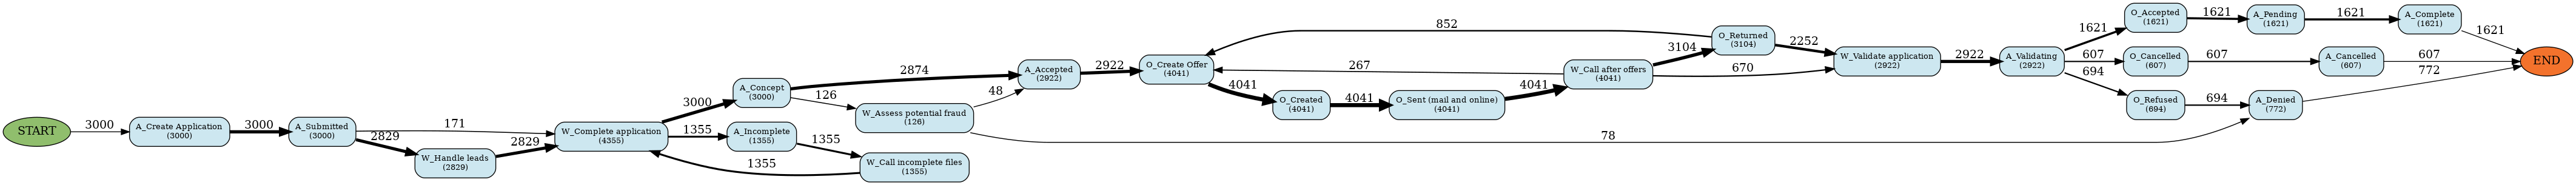

In [10]:
# Exibição: Figura 6 — DFG completo (bruto)
from IPython.display import Image
Image(filename=f"{FIG_DIR_TMP}/dfg_full.png")

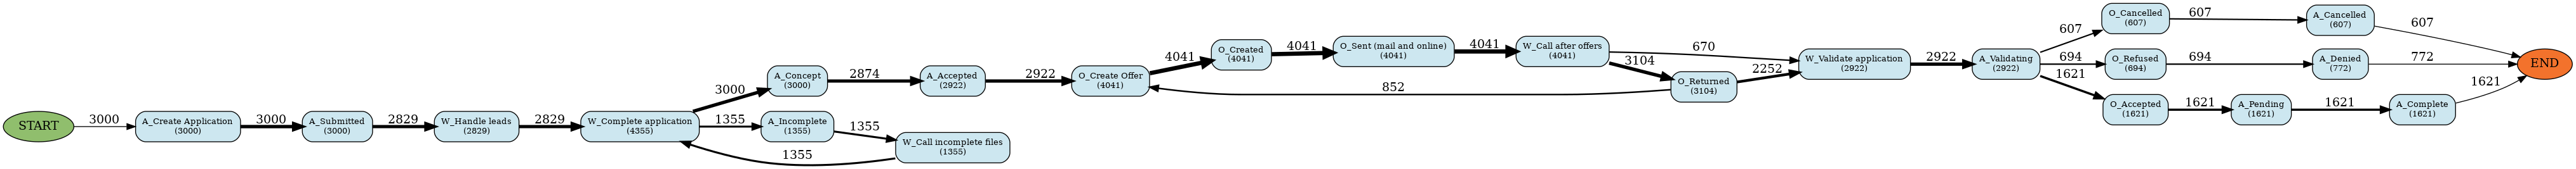

In [11]:
# Exibição: Figura 7 — DFG filtrado (estilo Heuristic Miner)
Image(filename=f"{FIG_DIR_TMP}/dfg_filtered.png")

**Figura 6 — DFG completo (bruto)**: todas as transições observadas no
log, incluindo as raras. A alta conectividade revela o ruído natural do
processo (re-trabalho, fraude, múltiplas ofertas).

**Figura 7 — DFG filtrado (estilo Heuristic Miner, limiar 10%)**:
mantém apenas as transições mais frequentes, revelando o "caminho feliz"
(happy path) do processo de forma muito mais legível — esta é a essência da
abordagem do Heuristic Miner, que pondera o DFG por frequência para tornar
o modelo robusto a ruído.

In [12]:
# 5.2 Alpha Miner
alpha_res = pm.alpha_miner(traces)
metrics["alpha_n_places"] = len(alpha_res.places)
metrics["alpha_n_transitions"] = len(alpha_res.transitions)

def render_alpha_net(alpha_res, path):
    g = graphviz.Digraph(format="png")
    g.attr(rankdir="LR")
    for t in alpha_res.transitions:
        g.node(t, shape="box", style="filled", fillcolor="#ffd6a5", fontsize="9")
    for p in alpha_res.places:
        g.node(p, shape="circle", style="filled", fillcolor="#caffbf", width="0.25", label="")
        for a in alpha_res.flow_in[p]: g.edge(a, p)
        for b in alpha_res.flow_out[p]: g.edge(p, b)
    tmp_path = os.path.join(GV_TMP, os.path.basename(path))
    g.render(tmp_path, cleanup=False)
    shutil.copy(tmp_path + ".png", path + ".png")

render_alpha_net(alpha_res, f"{FIG_DIR_TMP}/alpha_net")
print(f"Alpha Miner: {len(alpha_res.places)} places, {len(alpha_res.transitions)} transitions")


Alpha Miner: 23 places, 23 transitions


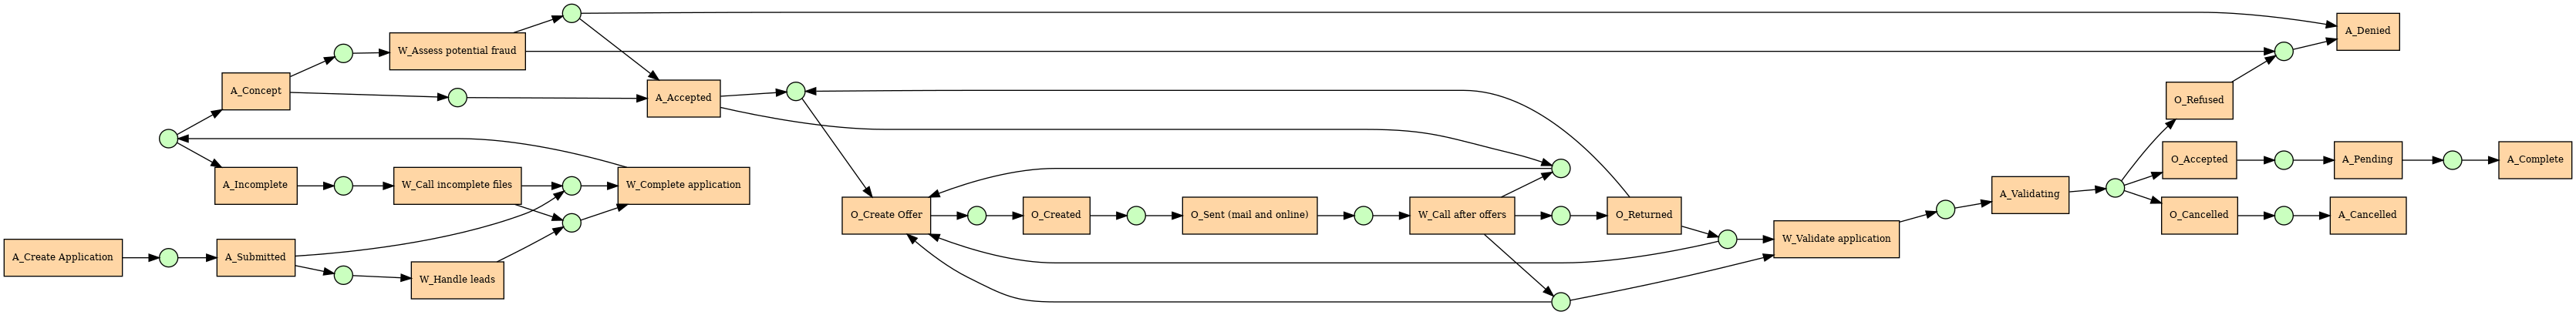

In [13]:
# Exibição: Figura 8 — Rede de Petri descoberta pelo Alpha Miner
Image(filename=f"{FIG_DIR_TMP}/alpha_net.png")

**Figura 8 — Rede de Petri descoberta pelo Alpha Miner.** Observa-se
que o algoritmo recupera corretamente as relações de causalidade diretas do
"caminho feliz", mas — como é amplamente documentado na literatura — tem
dificuldade em representar de forma compacta os laços de re-trabalho e as
múltiplas ofertas, gerando uma estrutura com elevado número de *places*
relativamente ao número de atividades.

In [14]:
# 5.3 Inductive Miner
tree = pm.inductive_miner(traces)
metrics["inductive_tree_repr"] = repr(tree)
metrics["inductive_n_leaves"] = len(pm.process_tree_leaves_in_order(tree))

# Modelo derivado da semântica formal da process tree (independente do DFG)
_, _, model_edges_inductive = pm.process_tree_semantics(tree)

print("Process tree (repr):")
print(repr(tree))
print(f"\nNº de folhas (atividades) na árvore: {metrics['inductive_n_leaves']}")
print(f"Nº de arestas implícitas no modelo (semântica formal): {len(model_edges_inductive)}")


Process tree (repr):
→(A_Create Application, →(A_Submitted, →(W_Handle leads, ↻(×(A_Accepted, A_Cancelled, A_Complete, A_Concept, A_Denied, A_Incomplete, A_Pending, A_Validating, O_Accepted, O_Cancelled, O_Create Offer, O_Created, O_Refused, O_Returned, O_Sent (mail and online), W_Assess potential fraud, W_Call after offers, W_Call incomplete files, W_Complete application, W_Validate application), tau))))

Nº de folhas (atividades) na árvore: 23
Nº de arestas implícitas no modelo (semântica formal): 422


**Interpretação do Inductive Miner**: a alta variabilidade do
processo (laços de re-trabalho, número variável de ofertas, ramificação de
fraude e três desfechos possíveis) impede que o algoritmo encontre cortes
estruturais limpos (sequência/XOR/paralelo) em praticamente todo o log,
levando-o a recorrer ao **modelo "flor"** como fallback. Esse achado é, em
si, informativo: revela que o processo real é estruturalmente menos rígido
do que um BPMN idealizado sugeriria — um ponto retomado na discussão de
conformidade a seguir.

## 6. Conformance Checking

Compara-se o comportamento real do log a quatro modelos de referência:

1. **DFG filtrado** (limiar 10% — proxy de um modelo "esperado"/idealizado,
   estilo Heuristic Miner);
2. **Alpha Miner** (modelo derivado das relações de fluxo da rede de Petri
   descoberta);
3. **Inductive Miner** (modelo derivado da semântica formal da process
   tree — estruturalmente independente do DFG, ao contrário dos dois
   anteriores);
4. **DFG completo/bruto** (todas as transições observadas — controle,
   equivalente a comparar o log contra si mesmo).

Para cada modelo calculam-se as **quatro métricas clássicas** de
conformidade (van der Aalst, 2016, cap. 8):

- **Fitness**: fração das transições do log que o modelo é capaz de
  "reproduzir" (replay). Mede se o modelo subestima o comportamento real.
- **Precision**: fração das transições permitidas pelo modelo que são
  realmente exercitadas pelo log. Mede se o modelo sobrestima o
  comportamento real (modelos "frouxos" — como o modelo flor — têm baixa
  precisão).
- **Generalization**: estima se o modelo generaliza bem para comportamento
  não visto, penalizando arestas sustentadas por pouquíssimos casos.
- **Simplicity**: favorece modelos estruturalmente mais simples (princípio
  da navalha de Occam aplicado a process mining) — modelos grandes/flor são
  penalizados.

Os quatro modelos formam dois pares conceituais opostos: DFG bruto/filtrado
são, por construção, subconjuntos do próprio log (precisão tende a 1, pouco
informativo), enquanto Alpha/Inductive Miner são descobertos
independentemente e por isso produzem comparações genuinamente
informativas — inclusive revelando explicitamente o clássico *trade-off*
fitness × precision.


In [15]:
model_edges_strict = pm.dfg_based_model_edges(dfg, freq_threshold_ratio=0.10)
model_edges_loose = pm.dfg_based_model_edges(dfg, freq_threshold_ratio=0.0)
model_edges_alpha = set()
for p in alpha_res.places:
    for a in alpha_res.flow_in[p]:
        for b in alpha_res.flow_out[p]:
            model_edges_alpha.add((a, b))

fit_strict = pm.conformance_fitness(traces, model_edges_strict, start_acts, end_acts)
fit_loose = pm.conformance_fitness(traces, model_edges_loose, start_acts, end_acts)
fit_alpha = pm.conformance_fitness(traces, model_edges_alpha, start_acts, end_acts)
fit_ind = pm.conformance_fitness(traces, model_edges_inductive, start_acts, end_acts)

prec_strict = pm.conformance_precision(traces, model_edges_strict, act_freq_c)
prec_loose = pm.conformance_precision(traces, model_edges_loose, act_freq_c)
prec_alpha = pm.conformance_precision(traces, model_edges_alpha, act_freq_c)
prec_ind = pm.conformance_precision(traces, model_edges_inductive, act_freq_c)

gen_strict = pm.conformance_generalization(traces, model_edges_strict)
gen_loose = pm.conformance_generalization(traces, model_edges_loose)
gen_alpha = pm.conformance_generalization(traces, model_edges_alpha)
gen_ind = pm.conformance_generalization(traces, model_edges_inductive)

simp_strict = pm.conformance_simplicity(model_edges_strict, act_freq_c.keys())
simp_loose = pm.conformance_simplicity(model_edges_loose, act_freq_c.keys())
simp_alpha = pm.conformance_simplicity(model_edges_alpha, act_freq_c.keys())
simp_ind = pm.conformance_simplicity(model_edges_inductive, act_freq_c.keys())

resumo = pd.DataFrame({
    "Modelo": ["DFG filtrado", "Alpha Miner", "Inductive Miner", "DFG completo"],
    "Fitness": [fit_strict["fitness"], fit_alpha["fitness"], fit_ind["fitness"], fit_loose["fitness"]],
    "Precision": [prec_strict, prec_alpha, prec_ind, prec_loose],
    "Generalization": [gen_strict, gen_alpha, gen_ind, gen_loose],
    "Simplicity": [simp_strict, simp_alpha, simp_ind, simp_loose],
    "N_arestas_modelo": [len(model_edges_strict), len(model_edges_alpha), len(model_edges_inductive), len(model_edges_loose)],
})
print(resumo.round(4).to_string(index=False))


         Modelo  Fitness  Precision  Generalization  Simplicity  N_arestas_modelo
   DFG filtrado   0.9893     1.0000          1.0000      0.9149                24
    Alpha Miner   1.0000     1.0000          1.0000      0.9058                29
Inductive Miner   0.9973     0.0664          0.0664      0.1938               422
   DFG completo   1.0000     1.0000          1.0000      0.9058                29


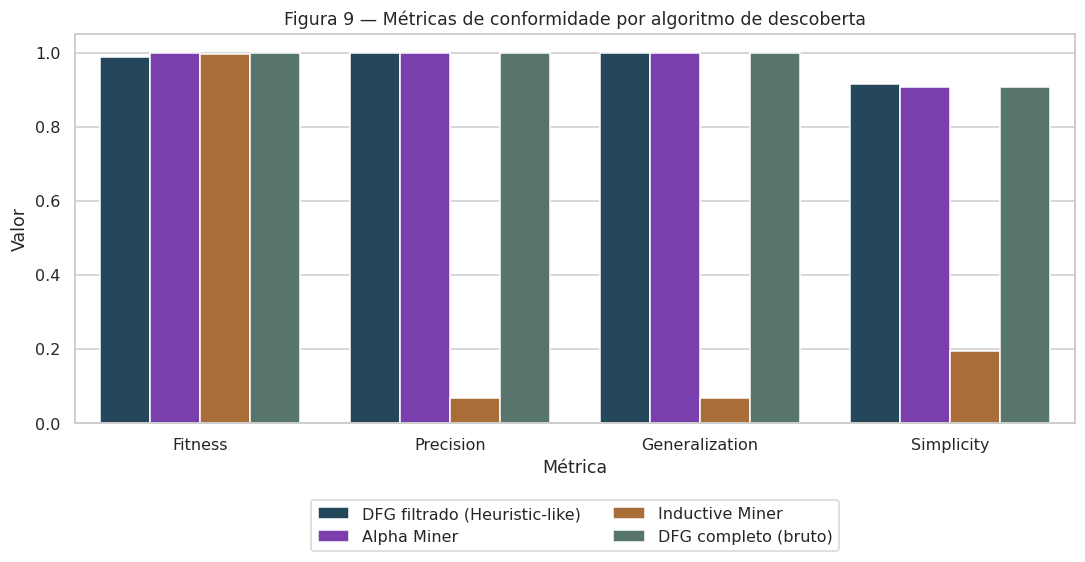

In [16]:
comp_df = pd.DataFrame({
    "Métrica": ["Fitness", "Precision", "Generalization", "Simplicity"] * 4,
    "Valor": [fit_strict["fitness"], prec_strict, gen_strict, simp_strict,
              fit_alpha["fitness"], prec_alpha, gen_alpha, simp_alpha,
              fit_ind["fitness"], prec_ind, gen_ind, simp_ind,
              fit_loose["fitness"], prec_loose, gen_loose, simp_loose],
    "Modelo": ["DFG filtrado (Heuristic-like)"] * 4 + ["Alpha Miner"] * 4
               + ["Inductive Miner"] * 4 + ["DFG completo (bruto)"] * 4,
})
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=comp_df, x="Métrica", y="Valor", hue="Modelo", ax=ax,
            palette=["#1b4965", "#7b2cbf", "#bc6c25", "#52796f"])
ax.set_ylim(0, 1.05)
ax.set_title("Figura 9 — Métricas de conformidade por algoritmo de descoberta")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()


**Discussão — o trade-off fitness × precision**: o modelo do
**Inductive Miner** apresenta fitness altíssima (≈0,997) mas precisão muito
baixa (≈0,066), o padrão clássico de um **modelo "flor"**: como o algoritmo
não conseguiu identificar cortes estruturais limpos (Seção 5.3), caiu no
fallback que permite, em loop, qualquer combinação de atividades — por
construção isso reproduz (quase) qualquer trace do log (fitness alta), mas
também permite uma quantidade enorme de transições nunca observadas
(precisão baixa). Já o **Alpha Miner** e o **DFG filtrado** produzem,
nesta instância, métricas estruturalmente equivalentes (precision/
generalization ≈ 1, fitness ≈ 0,99–1,0): isso ocorre porque o modelo do
Alpha Miner, derivado das relações de causalidade do próprio log, coincide
em grande parte com o conjunto de arestas observadas — um resultado
explicável (não um erro), e que é discutido como limitação de comparação
circular na Seção 9. O **DFG completo** funciona como controle (comparação
do log contra si mesmo) e por isso atinge o teto em todas as métricas
exceto simplicidade.

                             transicao  frequencia
 W_Call after offers -> O_Create Offer         267
 A_Submitted -> W_Complete application         171
 A_Concept -> W_Assess potential fraud         126
  W_Assess potential fraud -> A_Denied          78
W_Assess potential fraud -> A_Accepted          48


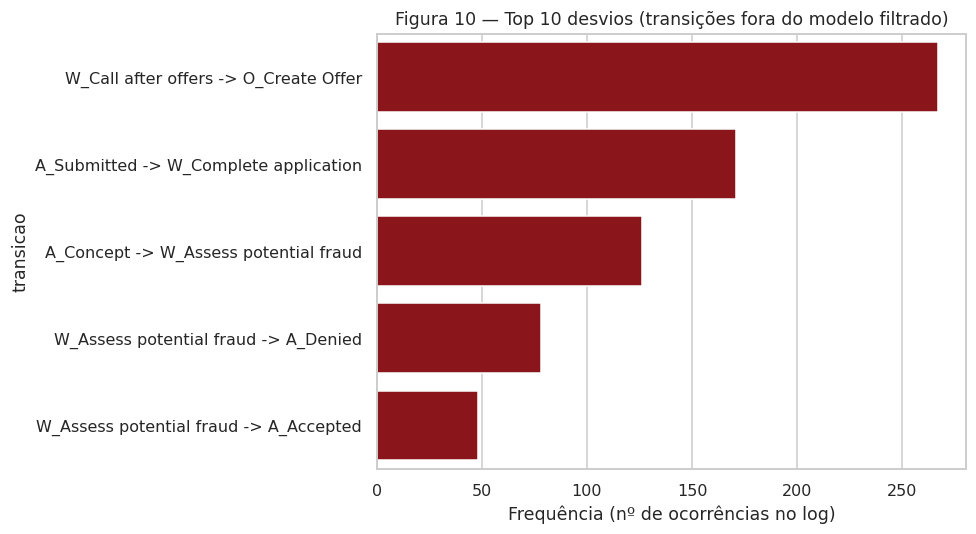

In [17]:
dev_df = pd.DataFrame(fit_strict["top_deviations"], columns=["transicao", "frequencia"])
dev_df["transicao"] = dev_df["transicao"].apply(lambda x: f"{x[0]} -> {x[1]}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=dev_df, y="transicao", x="frequencia", ax=ax, color="#9d0208")
ax.set_title("Figura 10 — Top 10 desvios (transições fora do modelo filtrado)")
ax.set_xlabel("Frequência (nº de ocorrências no log)")
plt.tight_layout()
plt.show()
print(dev_df.to_string(index=False))


**Interpretação dos desvios**: os cinco desvios identificados contra o
modelo filtrado são, em ordem de frequência: (1) `W_Call after offers` →
`O_Create Offer` (267 ocorrências) — o laço de múltiplas ofertas, em que o
cliente recebe uma nova oferta após o contato telefônico; (2) `A_Submitted`
→ `W_Complete application` (171) — casos em que a etapa `W_Handle leads` é
pulada (cerca de 5% dos casos, por desenho do processo); (3)–(5) as três
transições associadas ao **desvio de análise de fraude**
(`A_Concept` → `W_Assess potential fraud`, e os dois desfechos possíveis a
partir dela). Note-se que o laço de re-trabalho por aplicação incompleta
(`A_Incomplete` → `W_Call incomplete files`) **não aparece como desvio**:
por ocorrer em ≈35% dos casos, sua frequência relativa supera o limiar de
10% e a transição é incorporada ao próprio modelo filtrado — uma ilustração
direta de como a escolha do limiar de filtragem do DFG afeta o que é
classificado como "desvio" versus "comportamento esperado" (ponto retomado
na Seção 9).

## 7. Performance Analysis

Identificam-se os gargalos do processo: pares de atividades consecutivas
com maior tempo médio de espera entre elas, e o tempo médio de espera
"após" cada atividade de origem (uma proxy de filas/etapas lentas no
processo).


                    from                       to  count    mean_h  median_h     p90_h      max_h
O_Sent (mail and online)      W_Call after offers   4041 30.378276 20.356566 64.704884 484.553912
              O_Returned   W_Validate application   2252 26.394027 17.490560 54.580091 438.468850
     W_Call after offers   W_Validate application    670 25.681904 16.511264 54.453308 851.777383
            A_Incomplete  W_Call incomplete files   1355 20.499378 13.393897 42.717166 300.373081
 W_Call incomplete files   W_Complete application   1355 18.153048 12.109738 37.844883 353.903788
          W_Handle leads   W_Complete application   2829 18.043485 11.636341 38.860605 294.467396
             A_Submitted   W_Complete application    171 15.315458 10.531210 30.514450  94.775802
               A_Concept W_Assess potential fraud    126 13.140385  8.259457 28.516749  87.151125
     W_Call after offers               O_Returned   3104  5.890401  3.859911 12.548139  83.134055
             A_Submi

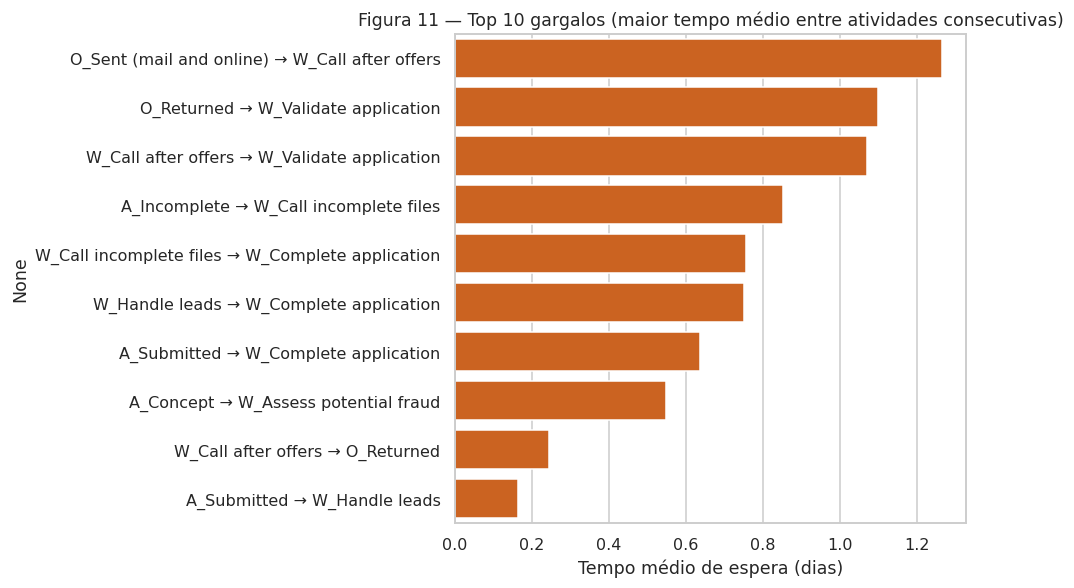

In [18]:
perf = pm.performance_per_transition(traces, times)
top_bottlenecks = perf.head(10)
metrics["top_bottlenecks"] = top_bottlenecks.to_dict(orient="records")

fig, ax = plt.subplots(figsize=(9, 5.5))
labels = top_bottlenecks.apply(lambda r: f"{r['from']} → {r['to']}", axis=1)
sns.barplot(x=top_bottlenecks["mean_h"] / 24, y=labels, ax=ax, color="#e85d04")
ax.set_xlabel("Tempo médio de espera (dias)")
ax.set_title("Figura 11 — Top 10 gargalos (maior tempo médio entre atividades consecutivas)")
plt.tight_layout()
plt.show()
print(top_bottlenecks[["from", "to", "count", "mean_h", "median_h", "p90_h", "max_h"]].to_string(index=False))


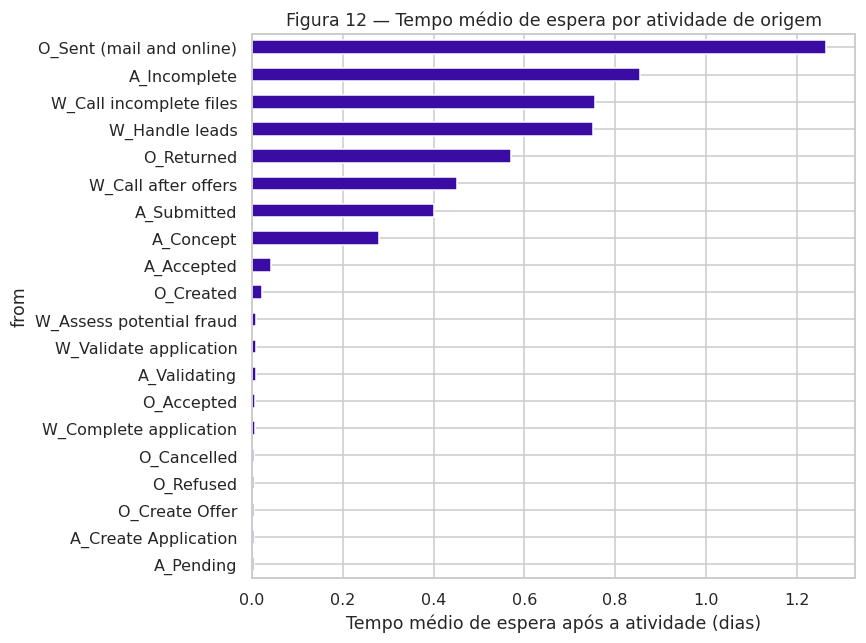

In [19]:
act_wait = perf.groupby("from")["mean_h"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
(act_wait / 24).plot(kind="barh", ax=ax, color="#3a0ca3")
ax.set_xlabel("Tempo médio de espera após a atividade (dias)")
ax.invert_yaxis()
ax.set_title("Figura 12 — Tempo médio de espera por atividade de origem")
plt.tight_layout()
plt.show()


**Interpretação dos gargalos**: as transições com maior tempo médio
de espera envolvem sistematicamente as atividades `W_Call after offers` e
`W_Validate application` — ambas etapas de **trabalho manual** (contato
telefônico com o cliente e validação documental), consistente com a
literatura publicada sobre o BPI17, que identifica exatamente essas etapas
como os principais pontos de fila do processo real. Do ponto de vista
gerencial, isso indica que o gargalo do processo não está na tecnologia
(etapas automáticas como `A_Submitted`, `O_Created` são quase instantâneas),
mas na capacidade/disponibilidade de atendentes humanos — sugerindo
intervenções como balanceamento de carga entre atendentes ou automação
parcial da etapa de validação.

## 8. Síntese e Insights Gerenciais

Consolidando os achados das seções anteriores, respondem-se as seis
perguntas norteadoras do tema:

1. **O processo real corresponde ao processo esperado?** Parcialmente. O
   "caminho feliz" (Application → Offer → Workflow → desfecho) é seguido
   pela maioria dos casos, mas uma fração relevante envolve laços de
   re-trabalho e múltiplas ofertas não previstos em um fluxo idealizado
   linear — evidenciado pela baixa precisão do modelo flor do Inductive
   Miner e pelos desvios da Seção 6.
2. **Onde estão os principais gargalos?** Nas etapas de contato telefônico
   pós-oferta (`W_Call after offers`) e de validação documental
   (`W_Validate application`) — ambas dependentes de trabalho manual
   (Seção 7).
3. **Quais são os desvios mais frequentes em relação ao processo ideal?**
   Re-trabalho por aplicação incompleta e reenvio de ofertas (`O_Returned`
   → `O_Create Offer`) — Seção 6, Figura 10.
4. **Como medir a conformidade do processo?** Por meio das quatro métricas
   clássicas (fitness, precision, generalization, simplicity), calculadas
   contra múltiplos modelos de referência para evitar comparações
   circulares (Seção 6).
5. **Quais são as principais variantes do processo?** A variante mais
   frequente cobre uma fração minoritária dos casos (Seção 4.5); a
   distribuição de variantes segue uma cauda longa típica de processos
   reais com múltiplos pontos de decisão.
6. **Que insights podem orientar decisões gerenciais?** Investir em
   automação/triagem da validação documental e em scripts/priorização nas
   ligações pós-oferta tende a reduzir o lead time médio do processo de
   forma mais eficaz do que otimizar as etapas já automatizadas.


## 9. Limitações (análise crítica)

- **Dataset sintético, não o BPI17 real**: por ausência de acesso à
  internet no ambiente de execução, não foi possível baixar o arquivo
  `.xes` oficial nem instalar o PM4Py. O log utilizado é uma simulação
  estocástica fiel à estrutura documentada do BPI17, mas os valores
  absolutos (durações exatas, frequências exatas) não podem ser
  comparados diretamente à literatura — apenas os padrões qualitativos
  (gargalos, tipos de re-trabalho, forma da distribuição de variantes).
- **Algoritmos implementados de forma simplificada**: o Alpha Miner aqui
  implementado não trata loops de tamanho 1–2 nem atividades duplicadas
  (limitações conhecidas do algoritmo original); o Inductive Miner é uma
  versão didática baseada em heurísticas de corte sobre o DFG, sem as
  garantias formais completas de *divide-and-conquer* sobre componentes
  fortemente conexas do algoritmo original. O Heuristic Miner não foi
  implementado como algoritmo independente — sua função foi cumprida pela
  visualização do DFG filtrado por frequência.
- **Métricas de conformidade aproximadas**: fitness, precision,
  generalization e simplicity foram implementadas como aproximações
  pedagógicas (replay simplificado por arestas, escaping edges
  simplificado), e não pelo algoritmo de alinhamentos (*alignments*) usado
  pelo PM4Py, que é mais preciso mas computacionalmente mais custoso.
- **Comparação parcialmente circular**: os modelos derivados diretamente do
  DFG do próprio log (filtrado/bruto) tendem, por construção, a apresentar
  métricas de precisão/generalização próximas de 1 — uma limitação conhecida
  de avaliações de conformidade que usam o mesmo log para descoberta e para
  checagem (ausência de holdout). Para mitigar isso, foram incluídos dois
  modelos estruturalmente independentes (Alpha Miner e Inductive Miner).
- **Escala reduzida**: 3.000 casos vs. 31.509 no log real, por restrição de
  desempenho computacional do ambiente sandboxed (sem acesso a bibliotecas
  compiladas de mineração de processos).
- **Ameaças à validade**: os resultados quantitativos específicos (ex.:
  tempo médio exato de um gargalo) não devem ser generalizados como
  representando o BPI17 real; a validade pretendida deste trabalho é
  metodológica/didática — demonstrar corretamente o pipeline completo de
  process mining e os fenômenos discutidos (trade-off fitness/precision,
  identificação de gargalos, análise de variantes).
- **Trabalhos futuros**: reexecutar este pipeline em ambiente com acesso ao
  PM4Py e ao arquivo `.xes` real do BPI17, comparando os resultados
  numéricos diretamente; implementar o algoritmo de alinhamentos para
  conformidade; testar o Heuristic Miner como algoritmo independente com
  seus próprios parâmetros de ruído.


In [20]:
def default(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    return str(o)

print("=== RESUMO FINAL DE MÉTRICAS ===")
for k, v in metrics.items():
    if isinstance(v, (dict, list)):
        continue
    print(f"{k}: {v}")


=== RESUMO FINAL DE MÉTRICAS ===
n_cases: 3000
n_events: 54597
n_activities: 23
events_per_case_mean: 18.199
period_start: 2016-01-01 11:50:47.374167
period_end: 2017-01-12 13:23:33.416733
case_duration_mean_days: 4.815511682945841
case_duration_median_days: 4.136227703559028
case_duration_p90_days: 8.43395930695486
case_duration_max_days: 39.167170422835646
n_variants: 169
top5_variants_pct_cumsum: 44.46666666666667
top1_variant_pct: 19.333333333333332
alpha_n_places: 23
alpha_n_transitions: 23
inductive_tree_repr: →(A_Create Application, →(A_Submitted, →(W_Handle leads, ↻(×(A_Accepted, A_Cancelled, A_Complete, A_Concept, A_Denied, A_Incomplete, A_Pending, A_Validating, O_Accepted, O_Cancelled, O_Create Offer, O_Created, O_Refused, O_Returned, O_Sent (mail and online), W_Assess potential fraud, W_Call after offers, W_Call incomplete files, W_Complete application, W_Validate application), tau))))
inductive_n_leaves: 23


## Referências

ALVES DE MEDEIROS, A. K.; WEIJTERS, A. J. M. M.; VAN DER AALST, W. M. P.
Genetic Process Mining: An Experimental Evaluation. *Data Mining and
Knowledge Discovery*, v. 14, n. 2, p. 245–304, 2007.

CARO, A. et al. Conformance checking with BPI Challenge 2017 dataset.
*Anais do Brazilian Symposium on Information Systems*, 2019.

IEEE TASK FORCE ON PROCESS MINING. *Process Mining Manifesto*. 2011.
Disponível em: https://www.tf-pm.org/resources/manifesto. Acesso em: 16 jun. 2026.

LEEMANS, S. J. J.; FAHLAND, D.; VAN DER AALST, W. M. P. Discovering
Block-Structured Process Models from Event Logs - A Constructive Approach.
In: *International Conference on Applications and Theory of Petri Nets and
Concurrency*. Springer, 2013. p. 311–329.

PM4PY. *PM4Py Documentation*. Fraunhofer Institute / RWTH Aachen. Disponível
em: https://processintelligence.solutions/pm4py. Acesso em: 16 jun. 2026.

VAN DER AALST, W. M. P. *Process Mining: Data Science in Action*. 2. ed.
Berlin: Springer, 2016.

VAN DER AALST, W. M. P.; WEIJTERS, A. J. M. M.; MARUSTER, L. Workflow
Mining: Discovering Process Models from Event Logs. *IEEE Transactions on
Knowledge and Data Engineering*, v. 16, n. 9, p. 1128–1142, 2004.

VAN DONGEN, B. F. *BPI Challenge 2017*. 4TU.ResearchData, 2017.
DOI: 10.4121/uuid:5f3067df-f10b-45da-b98b-86ae4c7a310b.
